# Large Backbone Ablation

Fair model comparison using the shared large-backbone setting: ViT-L/16 for encoder models and LTX-13B for LTX-Video.


# Large Backbone Ablation

This notebook compares models under a shared large-backbone setting. All encoder models use `ViT-L/16`; LTX uses `LTX-2B` and `LTX-13B`. For each dataset, probe, and model, the plotted value is the best test primary metric across the available large-backbone rows.

**Best-test rows used in the plot**

,Dataset,Model,Backbone,Experiment,Probe,Selected layer,Best test primary used for selection,Plotted test primary,Test accuracy
17,IntPhys2,LTX-13B,LTX-13B,ltx,Attentive,34,48.37,48.37,64.71
18,IntPhys2,LTX-2B,LTX-2B,ltx,Attentive,36,29.41,29.41,57.35
14,IntPhys2,V-JEPA,ViT-L/16,same_L,Attentive,18,72.55,72.55,83.33
15,IntPhys2,V-JEPA 2,ViT-L/16,same_L,Attentive,18,64.71,64.71,83.33
16,IntPhys2,V-JEPA 2.1,ViT-L/16,same_L,Attentive,24,67.32,67.32,72.55
19,IntPhys2,VideoMAE,ViT-L/16,same_L,Attentive,24,69.93,69.93,79.90
20,IntPhys2,VideoMAE-v2,ViT-L/16,same_L,Attentive,18,56.86,56.86,73.04
3,IntPhys2,LTX-13B,LTX-13B,ltx,Linear,noise_0.1_block_24,49.67,49.67,61.76
4,IntPhys2,LTX-2B,LTX-2B,ltx,Linear,noise_0.7_block_14,23.53,23.53,52.45
0,IntPhys2,V-JEPA,ViT-L/16,same_L,Linear,24,48.37,48.37,60.29


**Loaded-row coverage, not directly plotted**

,Dataset,Model,Backbone,Experiment,Probe,n_loaded_rows,best_validation_any_row,best_test_any_row
2,IntPhys2,LTX-13B,LTX-13B,ltx,Attentive,4,56.86,43.14
0,IntPhys2,LTX-13B,LTX-13B,ltx,Linear,40,45.10,49.02
1,IntPhys2,LTX-13B,LTX-13B,ltx,MLP,40,43.14,47.06
5,IntPhys2,LTX-2B,LTX-2B,ltx,Attentive,4,21.57,35.29
3,IntPhys2,LTX-2B,LTX-2B,ltx,Linear,40,29.41,27.45
4,IntPhys2,LTX-2B,LTX-2B,ltx,MLP,40,29.41,27.45
8,IntPhys2,V-JEPA,ViT-L/16,same_L,Attentive,4,78.43,74.51
6,IntPhys2,V-JEPA,ViT-L/16,same_L,Linear,4,43.14,47.06
7,IntPhys2,V-JEPA,ViT-L/16,same_L,MLP,4,50.98,49.02
11,IntPhys2,V-JEPA 2,ViT-L/16,same_L,Attentive,4,68.63,70.59


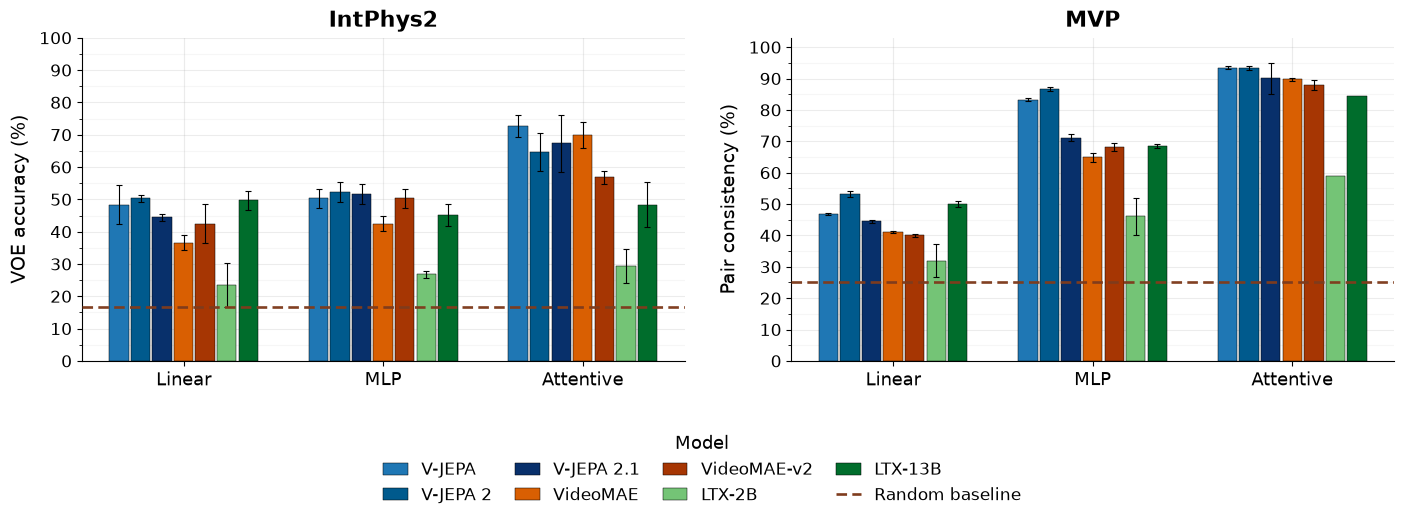

In [4]:
from pathlib import Path
import os
import re
import sys

os.environ.setdefault('MPLCONFIGDIR', '/tmp/probe4physics_matplotlib')
os.environ.setdefault('XDG_CACHE_HOME', '/tmp/probe4physics_cache')
Path(os.environ['MPLCONFIGDIR']).mkdir(parents=True, exist_ok=True)
Path(os.environ['XDG_CACHE_HOME']).mkdir(parents=True, exist_ok=True)

import importlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.ticker import MultipleLocator
try:
    import seaborn as sns
except Exception:
    sns = None

try:
    from IPython.display import Markdown, display
except ModuleNotFoundError:
    class Markdown(str):
        pass
    def display(obj):
        print(obj)

pd.set_option('display.max_columns', 160)
pd.set_option('display.width', 180)
if sns is not None:
    sns.set_theme(style='whitegrid', context='notebook')
else:
    plt.rcParams.update({'axes.grid': True, 'grid.alpha': 0.25})
plt.rcParams['figure.max_open_warning'] = 0
plt.rcParams.update({
    'font.size': 12,
    'axes.titlesize': 14,
    'axes.labelsize': 13,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'legend.fontsize': 11,
})

def find_repo_root(start=None):
    current = Path.cwd() if start is None else Path(start)
    for candidate in [current, *current.parents]:
        if (candidate / 'results').exists() and (candidate / 'run.py').exists():
            return candidate
    raise FileNotFoundError('Could not find repository root containing results/ and run.py')

REPO_ROOT = find_repo_root()
NOTEBOOK_DIR = REPO_ROOT / 'notebooks'
if str(NOTEBOOK_DIR) not in sys.path:
    sys.path.insert(0, str(NOTEBOOK_DIR))
import plot_colors
importlib.reload(plot_colors)
from plot_colors import MODEL_COLORS, PROBE_COLORS, REFERENCE_COLORS
from seed_variance_loader import load_ready_seed_summary

RESULTS_DIR = REPO_ROOT / 'results'
MVP_XLSX = RESULTS_DIR / 'mvp_primary_db.xlsx'
INTPHYS_XLSX = RESULTS_DIR / 'intphys_primary_db.xlsx'

DATASET_ORDER = ['intphys2', 'mvp']
DATASET_LABEL = {'mvp': 'MVP', 'intphys2': 'IntPhys2'}
PRIMARY_LABEL = {'mvp': 'Pair consistency (%)', 'intphys2': 'VOE accuracy (%)'}
RANDOM_BASELINE = {'mvp': 25.0, 'intphys2': 100.0 / 6.0}
PROBE_ORDER = ['linear', 'mlp', 'temporal_attn']
PROBE_LABEL = {'linear': 'Linear', 'mlp': 'MLP', 'temporal_attn': 'Attentive'}
MODEL_ORDER = ['jepa_v1', 'jepa_v2', 'jepa_v2_1', 'videomae', 'videomae_v2', 'ltx_video_2b', 'ltx_video_13b']
MODEL_LABEL = {
    'jepa_v1': 'V-JEPA',
    'jepa_v2': 'V-JEPA 2',
    'jepa_v2_1': 'V-JEPA 2.1',
    'videomae': 'VideoMAE',
    'videomae_v2': 'VideoMAE-v2',
    'ltx_video_2b': 'LTX-2B',
    'ltx_video_13b': 'LTX-13B',
}
SHEET_TO_MODEL_KEY = {
    'V-JEPA': 'jepa_v1',
    'V-JEPA 2': 'jepa_v2',
    'V-JEPA 2.1': 'jepa_v2_1',
    'VideoMAE': 'videomae',
    'VideoMAE-v2': 'videomae_v2',
    'LTX-Video': 'ltx_video',
}
TARGET_BACKBONE = {
    'jepa_v1': 'ViT-L/16',
    'jepa_v2': 'ViT-L/16',
    'jepa_v2_1': 'ViT-L/16',
    'videomae': 'ViT-L/16',
    'videomae_v2': 'ViT-L/16',
    'ltx_video_2b': 'LTX-2B',
    'ltx_video_13b': 'LTX-13B',
}
TARGET_EXPERIMENT = {
    'jepa_v1': 'same_L',
    'jepa_v2': 'same_L',
    'jepa_v2_1': 'same_L',
    'videomae': 'same_L',
    'videomae_v2': 'same_L',
    'ltx_video_2b': 'ltx',
    'ltx_video_13b': 'ltx',
}

for required in [MVP_XLSX, INTPHYS_XLSX]:
    if not required.exists():
        raise FileNotFoundError(f'Missing required workbook: {required}')


SEED_VARIANCE_MODE = 'attentive_continuation'  # 'original' or 'attentive_continuation'
SEED_SUMMARY_CSV = RESULTS_DIR / 'seed_runs' / 'complete_seed_results_so_far_summary.csv'
ATTENTIVE_CONTINUATION_CSV = RESULTS_DIR / 'seed_runs' / 'attentive_final_continuation_scientific_audit.csv'
SEED_MERGE_KEYS = ['dataset', 'experiment', 'model_label', 'backbone', 'probe', 'layer_key']
SEED_STAT_COLUMNS = [
    'n_seeds', 'seeds', 'seed_source',
    'test_primary_mean', 'test_primary_std', 'test_accuracy_mean', 'test_accuracy_std',
    'val_primary_mean', 'val_primary_std', 'val_accuracy_mean', 'val_accuracy_std',
]

def dataset_key(value):
    text = str(value).strip().lower()
    if text == 'intphys2':
        return 'intphys2'
    if text == 'mvp':
        return 'mvp'
    return text

def normalized_layer_label(value):
    if value is None or pd.isna(value):
        return ''
    text = re.sub(r'\s+', ' ', str(value).strip().lower())
    return text

def numeric_layer_key(value):
    number = pd.to_numeric(pd.Series([value]), errors='coerce').iloc[0]
    if pd.isna(number):
        return ''
    return f'id:{number:g}'

def label_layer_key(value):
    label = normalized_layer_label(value)
    return f'label:{label}' if label else ''

def row_layer_key(row):
    return numeric_layer_key(row.get('layer')) or label_layer_key(row.get('layer_label'))

def _empty_seed_summary():
    return pd.DataFrame(columns=SEED_MERGE_KEYS + SEED_STAT_COLUMNS)

def _expand_seed_layer_keys(df):
    if df.empty:
        return _empty_seed_summary()
    rows = []
    for key_func in (lambda row: numeric_layer_key(row.get('layer')), lambda row: label_layer_key(row.get('layer_label'))):
        keyed = df.copy()
        keyed['layer_key'] = keyed.apply(key_func, axis=1)
        keyed = keyed[keyed['layer_key'].astype(str).ne('')]
        if not keyed.empty:
            rows.append(keyed)
    if not rows:
        return _empty_seed_summary()
    return pd.concat(rows, ignore_index=True, sort=False)

def _dedupe_seed_summary(df):
    if df.empty:
        return _empty_seed_summary()
    out = _expand_seed_layer_keys(df)
    if out.empty:
        return _empty_seed_summary()
    for col in [c for c in SEED_STAT_COLUMNS if c.endswith('_mean') or c.endswith('_std')]:
        out[col] = pd.to_numeric(out[col], errors='coerce')
    out = out.sort_values(SEED_MERGE_KEYS + ['seed_source']).drop_duplicates(SEED_MERGE_KEYS, keep='last')
    return out[SEED_MERGE_KEYS + SEED_STAT_COLUMNS].reset_index(drop=True)

def _load_original_seed_summary():
    if not SEED_SUMMARY_CSV.exists():
        return _empty_seed_summary()
    seed = pd.read_csv(SEED_SUMMARY_CSV)
    seed = seed[seed['complete'].astype(str).str.lower().eq('true')].copy()
    seed['dataset'] = seed['dataset_hydra'].map(dataset_key)
    seed['model_label'] = seed['model'].astype(str)
    seed['probe'] = seed['probe_hydra'].map(canonical_probe)
    seed['layer'] = pd.to_numeric(seed['layer'], errors='coerce')
    seed['seed_source'] = 'original'
    return _dedupe_seed_summary(seed)

def _load_attentive_continuation_summary():
    if not ATTENTIVE_CONTINUATION_CSV.exists():
        return _empty_seed_summary()
    cont = pd.read_csv(ATTENTIVE_CONTINUATION_CSV)
    cont = cont[pd.to_numeric(cont['n_final_seeds'], errors='coerce').eq(3)].copy()
    cont['dataset'] = cont['dataset'].map(dataset_key)
    cont['model_label'] = cont['model'].astype(str)
    cont['probe'] = cont['probe'].map(canonical_probe)
    cont['layer'] = pd.to_numeric(cont['layer'], errors='coerce')
    cont['layer_label'] = ''
    cont['n_seeds'] = cont['n_final_seeds']
    cont['seeds'] = cont['final_seeds']
    cont['test_primary_mean'] = cont['final_test_primary_mean']
    cont['test_primary_std'] = cont['final_test_primary_std']
    cont['test_accuracy_mean'] = cont['final_test_accuracy_mean']
    cont['test_accuracy_std'] = cont['final_test_accuracy_std']
    cont['val_primary_mean'] = np.nan
    cont['val_primary_std'] = np.nan
    cont['val_accuracy_mean'] = np.nan
    cont['val_accuracy_std'] = np.nan
    cont['seed_source'] = 'attentive_continuation'
    return _dedupe_seed_summary(cont)

def load_seed_summary(mode=SEED_VARIANCE_MODE):
    return load_ready_seed_summary(
        RESULTS_DIR,
        mode=mode,
        seed_merge_keys=SEED_MERGE_KEYS,
        seed_stat_columns=SEED_STAT_COLUMNS,
    )

def attach_seed_stats(df, mode=SEED_VARIANCE_MODE):
    seeds = load_seed_summary(mode)
    base = df.drop(columns=[c for c in [*SEED_STAT_COLUMNS, 'layer_key'] if c in df.columns], errors='ignore').copy()
    base['layer'] = pd.to_numeric(base['layer'], errors='coerce')
    base['layer_key'] = base.apply(row_layer_key, axis=1)
    merged = base.merge(seeds, on=SEED_MERGE_KEYS, how='left', validate='many_to_one')
    merged['plot_test_primary'] = merged['test_primary_mean'].combine_first(merged['test_primary'])
    merged['plot_test_primary_std'] = pd.to_numeric(merged['test_primary_std'], errors='coerce')
    merged['plot_test_accuracy'] = merged['test_accuracy_mean'].combine_first(merged['test_accuracy'])
    merged['plot_test_accuracy_std'] = pd.to_numeric(merged['test_accuracy_std'], errors='coerce')
    merged['plot_val_primary'] = merged['val_primary_mean'].combine_first(merged['val_primary'])
    merged['plot_val_primary_std'] = pd.to_numeric(merged['val_primary_std'], errors='coerce')
    return merged

def yerr_or_none(values):
    err = pd.to_numeric(values, errors='coerce')
    return None if err.isna().all() else err.to_numpy(dtype=float)


def canonical_probe(value):
    text = str(value).strip().lower()
    if text == 'linear':
        return 'linear'
    if text == 'mlp':
        return 'mlp'
    if text in {'attentive', 'temporalattn', 'temporal_attn', 'temporal attentive'}:
        return 'temporal_attn'
    return text or None

def parse_ltx_slot(label):
    if label is None or pd.isna(label):
        return (np.nan, np.nan)
    match = re.search(r'noise_([0-9.]+)_block_(\d+)', str(label))
    if not match:
        return (np.nan, np.nan)
    return (float(match.group(1)), int(match.group(2)))

def parse_primary_workbook(path, dataset):
    frames = []
    xl = pd.ExcelFile(path)
    for sheet in xl.sheet_names:
        raw = xl.parse(sheet)
        cols = list(raw.columns)
        starts = [idx for idx, col in enumerate(cols) if not str(col).startswith('Unnamed') and 'primary metric' in str(col).lower()]
        for start in starts:
            end = min(start + 11, len(cols))
            title = str(cols[start])
            backbone = title.split(' - primary metric:', 1)[0].strip()
            block = raw.iloc[:, start:end].copy()
            headers = [str(item).strip() for item in block.iloc[0].tolist()]
            block = block.iloc[1:].copy()
            block.columns = headers
            block = block.dropna(how='all')
            if 'Experiment' not in block.columns:
                continue
            block = block[block['Experiment'].notna()].copy()
            if block.empty:
                continue
            block['dataset'] = dataset
            block['workbook'] = path.name
            block['sheet'] = sheet
            block['model_key'] = SHEET_TO_MODEL_KEY.get(sheet, sheet)
            block['backbone'] = backbone
            frames.append(block)
    if not frames:
        raise ValueError(f'No parseable result blocks found in {path}')
    return pd.concat(frames, ignore_index=True, sort=False)

def load_results():
    raw = pd.concat([
        parse_primary_workbook(INTPHYS_XLSX, 'intphys2'),
        parse_primary_workbook(MVP_XLSX, 'mvp'),
    ], ignore_index=True, sort=False)
    rename = {
        'Experiment': 'experiment',
        'Probe': 'probe_raw',
        'Layer': 'layer',
        'Layer Label': 'layer_label',
        'Selected LR': 'selected_lr',
        'Train Accuracy': 'train_accuracy',
        'Val Accuracy': 'val_accuracy',
        'Test Accuracy': 'test_accuracy',
        'Train Primary Metric': 'train_primary',
        'Val Primary Metric': 'val_primary',
        'Test Primary Metric': 'test_primary',
    }
    df = raw.rename(columns=rename).copy()
    df['probe'] = df['probe_raw'].map(canonical_probe)
    for col in ['layer', 'selected_lr', 'train_accuracy', 'val_accuracy', 'test_accuracy', 'train_primary', 'val_primary', 'test_primary']:
        df[col] = pd.to_numeric(df[col], errors='coerce')
    df['layer_label'] = df['layer_label'].astype('string')
    df['plot_model_key'] = df['model_key']
    df.loc[df['model_key'].eq('ltx_video') & df['backbone'].eq('LTX-2B'), 'plot_model_key'] = 'ltx_video_2b'
    df.loc[df['model_key'].eq('ltx_video') & df['backbone'].eq('LTX-13B'), 'plot_model_key'] = 'ltx_video_13b'
    df['model_label'] = df['plot_model_key'].map(MODEL_LABEL).fillna(df['sheet'])
    df['target_backbone'] = df['plot_model_key'].map(TARGET_BACKBONE)
    df['target_experiment'] = df['plot_model_key'].map(TARGET_EXPERIMENT)
    df['is_large_ablation_row'] = df['plot_model_key'].isin(MODEL_ORDER) & df['backbone'].eq(df['target_backbone']) & df['experiment'].eq(df['target_experiment'])
    slots = df['layer_label'].map(parse_ltx_slot)
    df['ltx_noise_level'] = [slot[0] for slot in slots]
    df['ltx_block'] = [slot[1] for slot in slots]
    df = attach_seed_stats(df)
    return df

def select_best_by_test(df):
    candidates = df.dropna(subset=['plot_test_primary']).copy()
    ordered = candidates.sort_values(['dataset', 'probe', 'plot_model_key', 'plot_test_primary', 'plot_test_accuracy', 'test_primary', 'val_primary'])
    best = ordered.groupby(['dataset', 'probe', 'plot_model_key'], group_keys=False).tail(1).copy()
    best['primary_score'] = best['plot_test_primary']
    best['primary_score_std'] = best['plot_test_primary_std']
    best['selection_score'] = best['plot_test_primary']
    return best.reset_index(drop=True)

def show_table(df, title):
    display(Markdown(f'**{title}**'))
    display(df.style.format(precision=2, na_rep=''))

all_results = load_results()
large_rows = all_results[all_results['is_large_ablation_row']].copy()
best_large = select_best_by_test(large_rows)

display(Markdown('# Large Backbone Ablation'))
display(Markdown(
    'This notebook compares models under a shared large-backbone setting. '
    'All encoder models use `ViT-L/16`; LTX uses `LTX-2B` and `LTX-13B`. '
    'For each dataset, probe, and model, the plotted value is the best test primary metric across the available large-backbone rows.'
))

summary = best_large.copy()
summary['Dataset'] = summary['dataset'].map(DATASET_LABEL)
summary['Probe'] = summary['probe'].map(PROBE_LABEL)
summary = summary.rename(columns={
    'model_label': 'Model',
    'backbone': 'Backbone',
    'experiment': 'Experiment',
    'layer_label': 'Selected layer',
    'selection_score': 'Best test primary used for selection',
    'primary_score': 'Plotted test primary',
    'test_accuracy': 'Test accuracy',
})
show_table(
    summary[['Dataset', 'Model', 'Backbone', 'Experiment', 'Probe', 'Selected layer', 'Best test primary used for selection', 'Plotted test primary', 'Test accuracy']]
    .sort_values(['Dataset', 'Probe', 'Model']),
    'Best-test rows used in the plot'
)

coverage = (
    large_rows.groupby(['dataset', 'model_label', 'backbone', 'experiment', 'probe'], as_index=False)
    .agg(n_loaded_rows=('test_primary', 'size'), best_validation_any_row=('val_primary', 'max'), best_test_any_row=('test_primary', 'max'))
)
coverage['Dataset'] = coverage['dataset'].map(DATASET_LABEL)
coverage['Probe'] = coverage['probe'].map(PROBE_LABEL)
coverage = coverage.rename(columns={
    'model_label': 'Model',
    'backbone': 'Backbone',
    'experiment': 'Experiment',
})
show_table(
    coverage[['Dataset', 'Model', 'Backbone', 'Experiment', 'Probe', 'n_loaded_rows', 'best_validation_any_row', 'best_test_any_row']]
    .sort_values(['Dataset', 'Model', 'Probe']),
    'Loaded-row coverage, not directly plotted'
)

def plot_large_ablation(best):
    fig, axes = plt.subplots(1, 2, figsize=(14.2, 5.2), sharey=False)
    model_colors = [MODEL_COLORS[key] for key in MODEL_ORDER]
    baseline_color = REFERENCE_COLORS['random_baseline']
    group_centers = np.arange(len(PROBE_ORDER))
    n_models = len(MODEL_ORDER)
    bar_width = 0.108
    offsets = (np.arange(n_models) - (n_models - 1) / 2.0) * bar_width

    legend_handles = []
    legend_labels = []
    for ax, dataset in zip(axes, DATASET_ORDER):
        ds = best[best['dataset'].eq(dataset)].copy()
        for model_idx, model_key in enumerate(MODEL_ORDER):
            heights = []
            errors = []
            for probe in PROBE_ORDER:
                row = ds[(ds['plot_model_key'].eq(model_key)) & (ds['probe'].eq(probe))]
                heights.append(np.nan if row.empty else float(row.iloc[0]['primary_score']))
                errors.append(np.nan if row.empty or pd.isna(row.iloc[0].get('primary_score_std')) else float(row.iloc[0]['primary_score_std']))
            yerr = None if np.isnan(np.asarray(errors, dtype=float)).all() else np.asarray(errors, dtype=float)
            bars = ax.bar(
                group_centers + offsets[model_idx],
                heights,
                width=bar_width * 0.9,
                color=model_colors[model_idx],
                edgecolor='black',
                linewidth=0.35,
                label=MODEL_LABEL[model_key],
                zorder=3,
                yerr=yerr,
                capsize=2.5,
                error_kw={'elinewidth': 0.8, 'capthick': 0.8},
            )
            if dataset == DATASET_ORDER[0]:
                legend_handles.append(bars[0])
                legend_labels.append(MODEL_LABEL[model_key])
        baseline = RANDOM_BASELINE[dataset]
        ax.axhline(
            baseline,
            color=baseline_color,
            linestyle=(0, (4, 2)),
            linewidth=1.9,
            alpha=0.98,
            zorder=6,
            solid_capstyle='butt',
            dash_capstyle='butt',
        )
        ax.set_title(DATASET_LABEL[dataset], fontsize=16, fontweight='bold', pad=8)
        ax.set_ylabel(PRIMARY_LABEL[dataset], fontsize=14, labelpad=7)
        ax.set_xticks(group_centers, [PROBE_LABEL[p] for p in PROBE_ORDER])
        ax.tick_params(axis='x', labelsize=13, pad=4)
        ax.tick_params(axis='y', labelsize=12)
        ax.yaxis.set_major_locator(MultipleLocator(10))
        ax.yaxis.set_minor_locator(MultipleLocator(5))
        ax.grid(axis='y', which='major', alpha=0.24, zorder=0)
        ax.grid(axis='y', which='minor', alpha=0.10, zorder=0)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ymax = max(100.0, np.nanmax((ds['primary_score'] + ds['primary_score_std'].fillna(0)).to_numpy(dtype=float)) + 8.0)
        ax.set_ylim(0, ymax)
    legend_handles.append(Line2D([0], [0], color=baseline_color, linestyle=(0, (4, 2)), linewidth=1.9))
    legend_labels.append('Random baseline')
    fig.legend(
        legend_handles,
        legend_labels,
        loc='lower center',
        bbox_to_anchor=(0.5, -0.035),
        ncol=4,
        frameon=False,
        title='Model',
        fontsize=12.2,
        title_fontsize=12.8,
        columnspacing=1.35,
        handlelength=1.45,
    )
    fig.tight_layout(rect=[0, 0.18, 1, 0.98], w_pad=2.1)
    return fig

plot_large_ablation(best_large)
plt.show()
